<a href="https://colab.research.google.com/github/noegmtz13/Modelos-Estadisticos-TEMD/blob/main/Proyecto_Final_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **<font color="red">Ajuste de Distribuciones de Probabilidad mediante MLE</font>**

## **<font color="navy">Integrantes del Equipo**
---

* Hernández Cruz Irene
* García Martínez Noé Antonio
* Martínez Ramírez Eduardo
* Velázquez Rodríguez Kenia Enid
* Villanueva Vargas Lynda Sarahi

---

## **<font color="navy">Información del Dataset</font>**

### **<font color="black">Nombre del dataset</font>**
Pima Indians Diabetes Database

### **<font color="black">Descripción</font>**
Este dataset contiene información médica de mujeres de ascendencia india Pima mayores de 21 años. El objetivo principal es predecir si una paciente presenta diabetes utilizando variables clínicas y biométricas.

### **<font color="black">Fuente</font>**
National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK)

### **<font color="black">Enlace</font>**
https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database



## **<font color="navy">Análisis Exploratorio**

### **<font color="navy">Contexto**
Este conjunto de datos proviene del **National Institute of Diabetes and Digestive and Kidney Diseases**.  


El objetivo es predecir la presencia de diabetes en pacientes a partir de diversas mediciones médicas.

La población analizada incluye exclusivamente mujeres mayores de 21 años de ascendencia indígena Pima.



### **<font color="navy">Variables del Dataset</font>**

<table style="border-collapse: collapse; width:100%; background-color:black; color:white;">

<tr style="background-color:black; color:white;">
<th style="padding:10px; border: 1px solid white;">Variable</th>
<th style="padding:10px; border: 1px solid white;">Descripción</th>
</tr>

<tr style="background-color:black; color:white;">
<td style="padding:10px; border: 1px solid white;"><b>Pregnancies</b></td>
<td style="padding:10px; border: 1px solid white;">Número de embarazos</td>
</tr>

<tr style="background-color:black; color:white;">
<td style="padding:10px; border: 1px solid white;"><b>Glucose</b></td>
<td style="padding:10px; border: 1px solid white;">Nivel de glucosa en plasma</td>
</tr>

<tr style="background-color:black; color:white;">
<td style="padding:10px; border: 1px solid white;"><b>BloodPressure</b></td>
<td style="padding:10px; border: 1px solid white;">Presión arterial diastólica (mm Hg)</td>
</tr>

<tr style="background-color:black; color:white;">
<td style="padding:10px; border: 1px solid white;"><b>SkinThickness</b></td>
<td style="padding:10px; border: 1px solid white;">Espesor del pliegue cutáneo (mm)</td>
</tr>

<tr style="background-color:black; color:white;">
<td style="padding:10px; border: 1px solid white;"><b>Insulin</b></td>
<td style="padding:10px; border: 1px solid white;">Nivel de insulina en suero (mu U/ml)</td>
</tr>

<tr style="background-color:black; color:white;">
<td style="padding:10px; border: 1px solid white;"><b>BMI</b></td>
<td style="padding:10px; border: 1px solid white;">Índice de masa corporal</td>
</tr>

<tr style="background-color:black; color:white;">
<td style="padding:10px; border: 1px solid white;"><b>DiabetesPedigreeFunction</b></td>
<td style="padding:10px; border: 1px solid white;">Probabilidad de diabetes por herencia</td>
</tr>

<tr style="background-color:black; color:white;">
<td style="padding:10px; border: 1px solid white;"><b>Age</b></td>
<td style="padding:10px; border: 1px solid white;">Edad</td>
</tr>

<tr style="background-color:black; color:white;">
<td style="padding:10px; border: 1px solid white;"><b>Outcome</b></td>
<td style="padding:10px; border: 1px solid white;">Variable objetivo (1 = Diabetes, 0 = No)</td>
</tr>

</table>


###**<font color="navy">Carga y visualización inicial de los datos**

Una vez descrito el contexto y las variables del dataset, se procede a cargar la base de datos y realizar una inspección preliminar.  
Esto permite verificar la estructura, dimensiones y contenido inicial del conjunto de datos.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
# Cargar datos
df = pd.read_csv("diabetes.csv")

# Vista inicial
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### **<font color="navy">Estructura del dataset**
En esta sección se analiza la estructura del dataset, incluyendo el número de observaciones, variables y tipos de datos.


In [ ]:
print("Dimensiones del dataset:")
print(df.shape)

print("\nTipos de variables:")
print(df.dtypes)


Dimensiones del dataset:
(768, 9)

Tipos de variables:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


####**<font color="navy">Resumen estadístico**

Se obtienen estadísticas descriptivas para entender la distribución general de las variables numéricas, incluyendo medidas como media, desviación estándar, mínimos y máximos.


In [ ]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### **<font color="navy">Calidad de datos**
Se identifican valores faltantes dentro del dataset.  
Como se puede observar la base esta completa.



In [ ]:
df.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### **<font color="navy">Distribución de la variable objetivo**

Se analiza la variable *Outcome*, que indica la presencia (1) o ausencia (0) de diabetes, con el fin de identificar posibles desbalances en las clases.

Se observa que la distribución de la variable objetivo está desbalanceada, con una mayor proporción de casos en la clase 0 (pacientes sin diabetes).


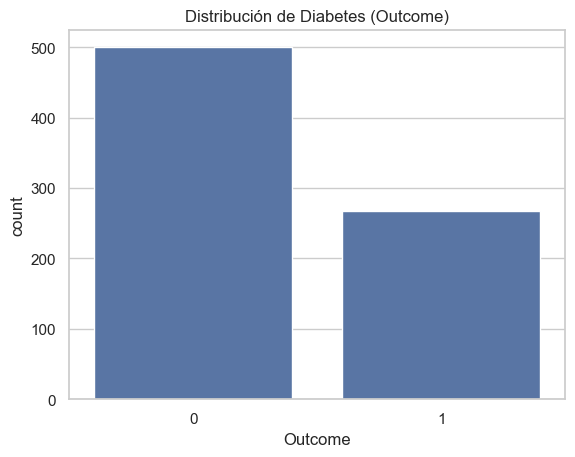

In [ ]:
plt.figure()
sns.countplot(x="Outcome", data=df)
plt.title("Distribución de Diabetes (Outcome)")
plt.show()


### **<font color="navy">Distribución de variables numéricas**

Se analizan las distribuciones individuales de las variables para identificar su forma (simetría, sesgo) y detectar posibles anomalías.


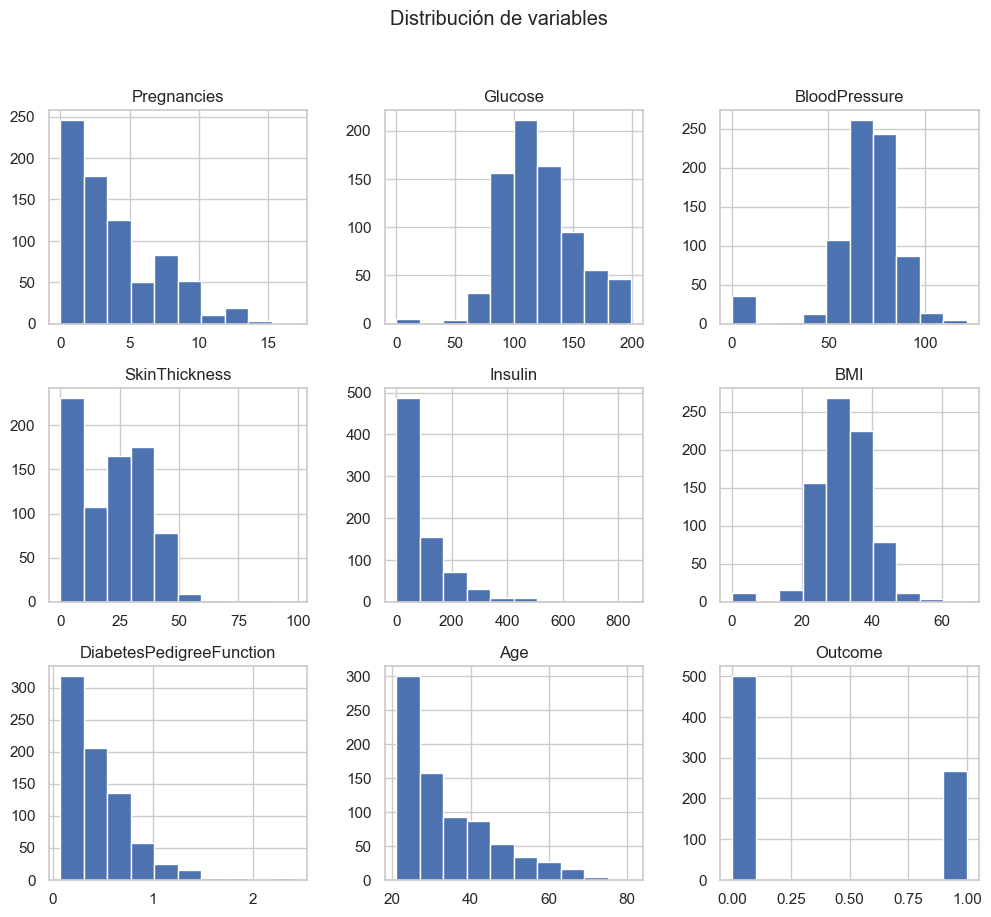

In [ ]:
df.hist(figsize=(12,10))
plt.suptitle("Distribución de variables")
plt.show()


### **<font color="navy">Detección de valores atípicos**


Se utilizan diagramas de caja (*boxplots*) para identificar la presencia de valores extremos que puedan afectar el análisis posterior.


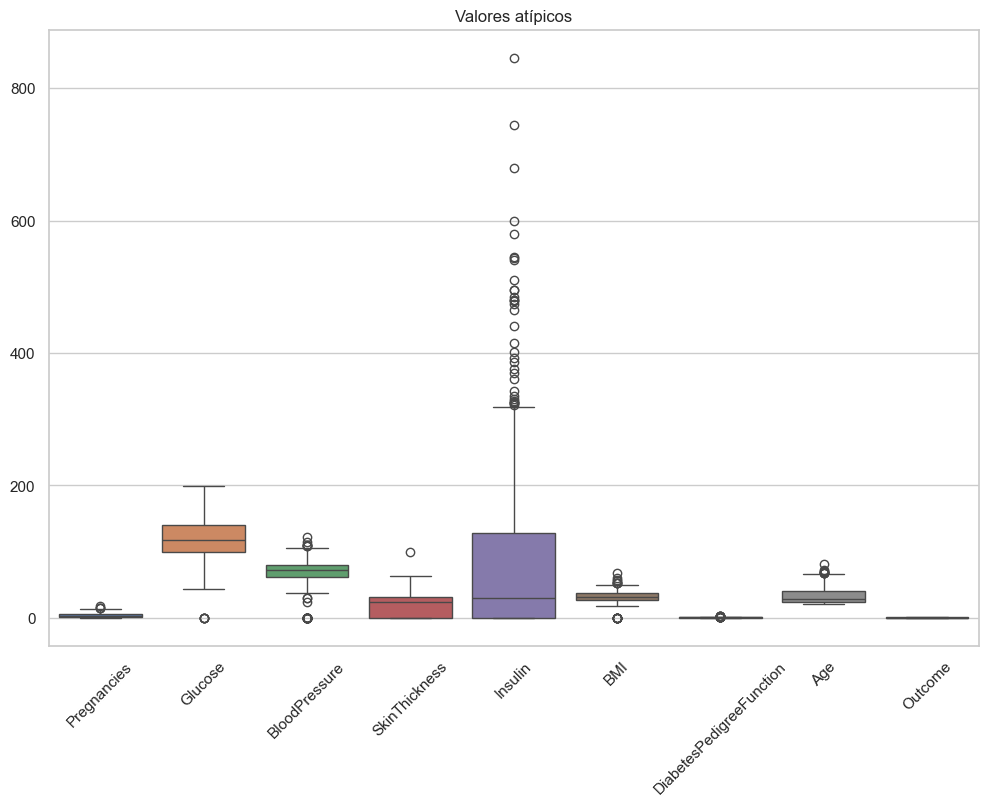

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Valores atípicos")
plt.show()


Se observa que las variables con mayor presencia de valores atípicos son `Insulin`, seguida de `BloodPressure` y `BMI`.


### **<font color="navy">Análisis de correlación**

Se evalúan las relaciones lineales entre las variables mediante una matriz de correlación, lo que permite identificar posibles asociaciones relevantes.


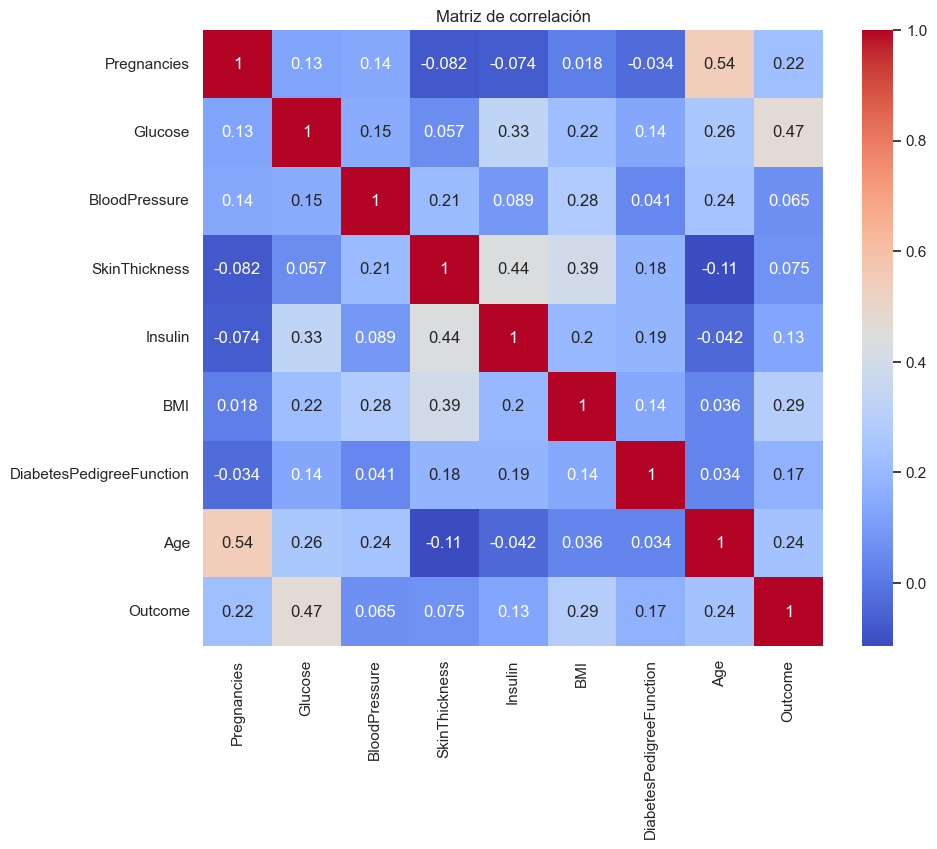

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()


 **Correlaciones más relevantes**

| Relación                  | Correlación | Interpretación            |
|---------------------------|------------|---------------------------|
| Glucose – Outcome         | 0.47       | Moderada positiva         |
| BMI – Outcome             | 0.29       | Débil a moderada positiva |
| Age – Outcome             | 0.24       | Débil positiva            |
| Pregnancies – Outcome     | 0.22       | Débil positiva            |
| Insulin – SkinThickness   | 0.44       | Moderada positiva         |
| Age – Pregnancies         | 0.54       | Moderada positiva         |


El análisis de correlación muestra que la variable `Glucose` presenta la relación más significativa con la variable objetivo (Outcome), lo que sugiere que es un factor relevante en la predicción de diabetes.

Asimismo, variables como `BMI`, `Age` y `Pregnancies` muestran correlaciones positivas, aunque de menor magnitud.

Por otro lado, se identifican relaciones moderadas entre variables independientes, como `Insulin` con `SkinThickness` y `Age` con `Pregnancies`, lo que indica posibles asociaciones internas dentro del conjunto de datos.

En general, la mayoría de las correlaciones son débiles, lo que sugiere que el fenómeno es multifactorial y no depende de una sola variable.


### **<font color="navy">Relación entre variables y diabetes**

Se analiza cómo algunas variables clave se comportan en función de la variable objetivo, con el fin de identificar patrones diferenciadores.


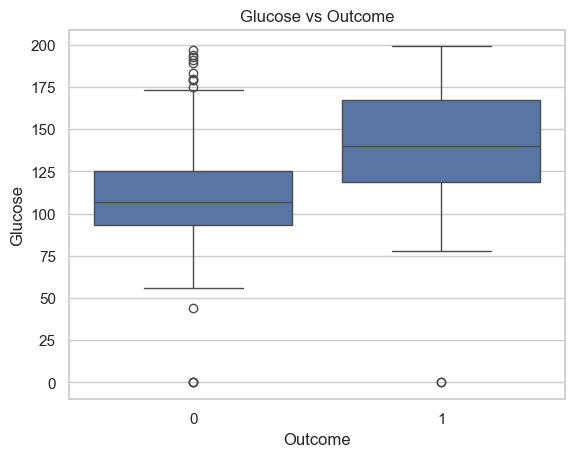

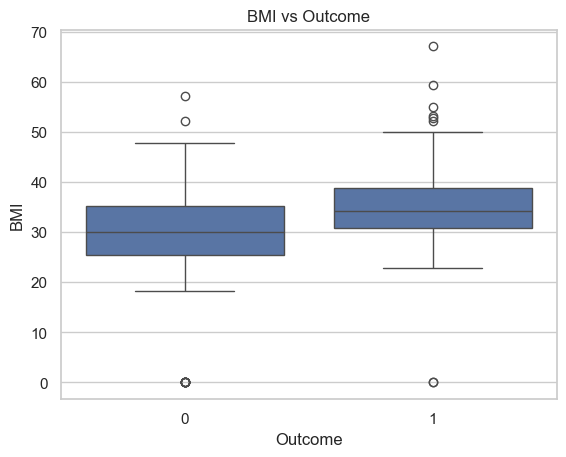

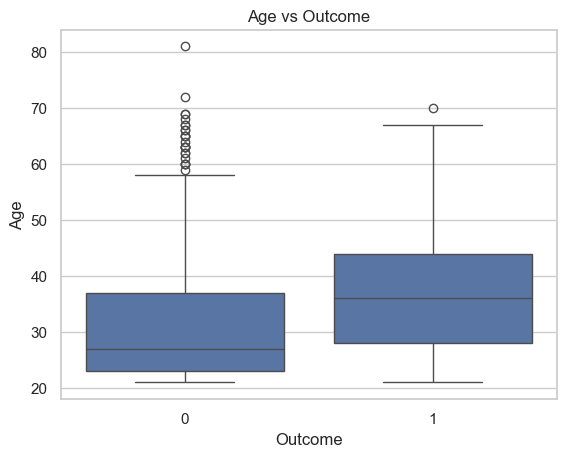

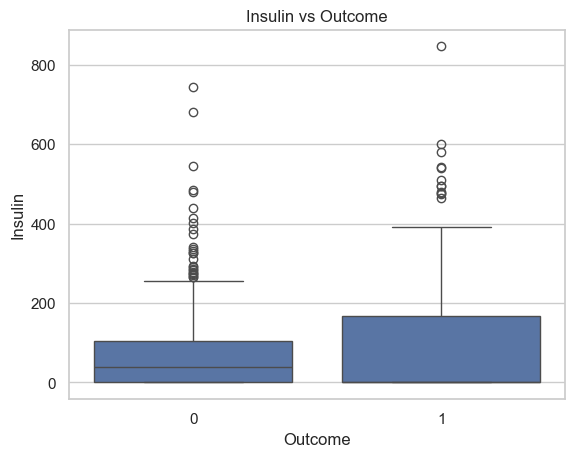

In [ ]:
variables = ["Glucose", "BMI", "Age", "Insulin"]

for var in variables:
    plt.figure()
    sns.boxplot(x="Outcome", y=var, data=df)
    plt.title(f"{var} vs Outcome")
    plt.show()


En la variable `Glucose`, se observa una diferencia clara entre las clases, donde la mediana de la clase 1 (pacientes con diabetes) es superior a la de la clase 0. Además, la mayor amplitud de la caja sugiere una mayor dispersión en los valores.

Para `BMI`, la clase 1 presenta una mediana ligeramente superior a la de la clase 0, aunque existe una considerable superposición entre ambas distribuciones, lo que indica una menor capacidad discriminante.

En el caso de `Age`, las cajas son similares en tamaño, pero la mediana de la clase 1 también es mayor, lo que sugiere una relación positiva moderada con la presencia de diabetes.

Por otro lado, en `Insulin`, no se observa un patrón claro. Aunque la dispersión es mayor en la clase 1, la mediana no muestra una diferencia consistente respecto a la clase 0, además de la presencia significativa de valores atípicos, lo que dificulta su interpretación.


###**<font color="navy">Análisis multivariado**


Se exploran relaciones conjuntas entre variables mediante gráficos de dispersión, diferenciando por la variable objetivo.


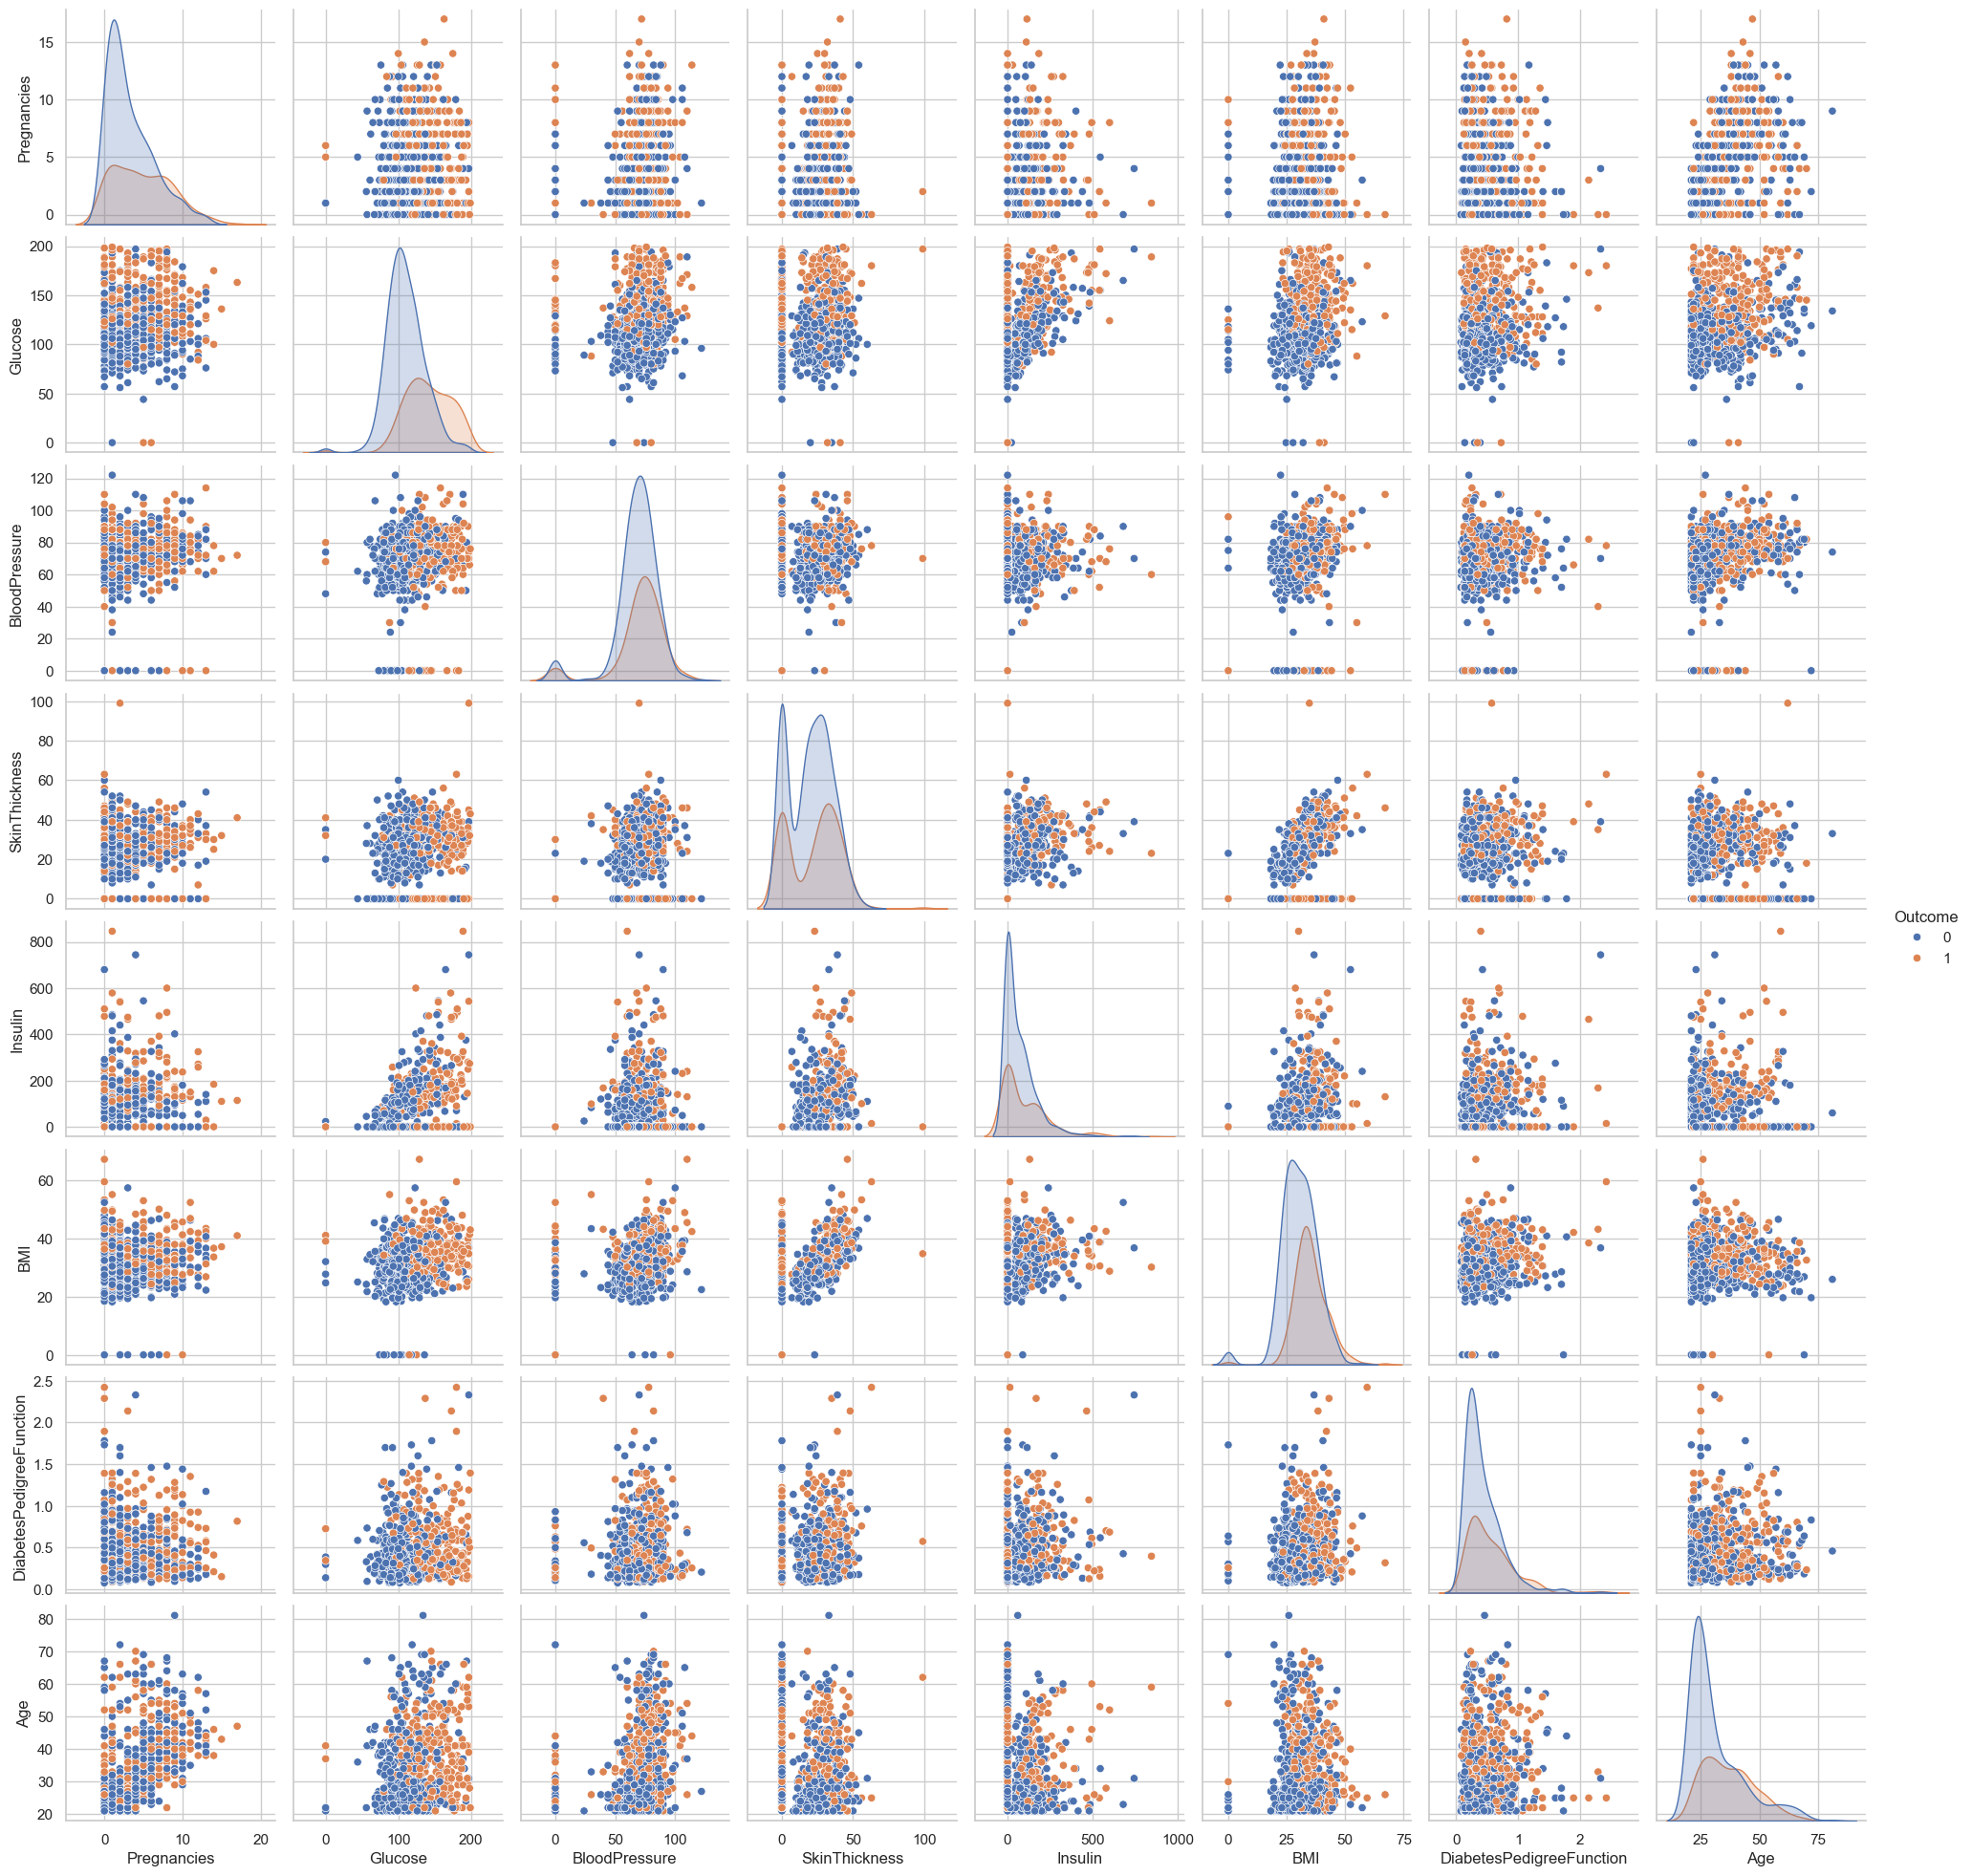

In [ ]:
sns.pairplot(df, hue="Outcome")
plt.show()


El análisis multivariado mediante gráficos de dispersión no muestra una separación clara entre las clases ni patrones definidos entre las variables.

Se observa una alta superposición entre los puntos correspondientes a pacientes con y sin diabetes, lo que sugiere que ninguna variable individual tiene una capacidad discriminante significativa.

Asimismo, no se identifican tendencias lineales claras entre las variables analizadas, lo que indica que las relaciones entre ellas son débiles o no lineales.

En conjunto, estos resultados sugieren que la presencia de diabetes es un fenómeno multifactorial, que depende de la interacción de múltiples variables más que de una sola en particular.


### **<font color="navy">Conclusiones del análisis exploratorio**


El análisis exploratorio permitió identificar que, en general, las variables presentan distribuciones asimétricas, presencia de valores atípicos y relaciones lineales débiles entre sí.

En particular, la variable `Glucose` muestra la asociación más relevante con la variable objetivo, mientras que variables como `BMI` y `Age` presentan relaciones moderadas. Por otro lado, `Insulin` evidencia alta dispersión y una cantidad significativa de valores atípicos, lo que dificulta su interpretación directa.

Asimismo, el análisis multivariado no muestra una separación clara entre las clases, lo que sugiere que la presencia de diabetes responde a un comportamiento multifactorial y no puede explicarse únicamente a partir de una sola variable.

Dado este contexto, resulta pertinente profundizar en el comportamiento probabilístico de las variables, con el fin de identificar distribuciones teóricas que describan adecuadamente sus patrones. En particular, se seleccionan variables como `BMI` para evaluar su ajuste a diferentes distribuciones de probabilidad, lo que permitirá caracterizar de manera más precisa su comportamiento estadístico.


## **<font color="navy">Ajuste de Distribuciones de Probabilidad</font>**

### **<font color="navy">Preparacion de los datos</font>**

Se realiza la limpieza de la variable **BMI**, identificando valores iguales a cero como no válidos, ya que no son físicamente posibles y representan valores faltantes en el conjunto de datos.

Por ello, dichos valores se reemplazan por valores nulos (NaN), evitando que afecten el análisis estadístico y el ajuste de modelos.

Posteriormente, se eliminan las observaciones con valores faltantes, trabajando únicamente con datos válidos.

Adicionalmente, se asegura que la variable contenga únicamente valores positivos, lo cual es un requisito fundamental para el ajuste de diversas distribuciones teóricas como **Lognormal, Gamma, Weibull o Inversa Gaussiana**.

Este proceso es especialmente importante en el contexto del **método de máxima verosimilitud (MLE)**, ya que valores inválidos o fuera del soporte de las distribuciones pueden generar estimaciones incorrectas o inestables.

Finalmente, se obtiene un conjunto de datos limpio y consistente, adecuado para el análisis descriptivo y el posterior ajuste de distribuciones.

In [ ]:
import numpy as np

# LIMPIEZA BMI

# Reemplazar ceros por NaN
df["BMI"] = df["BMI"].replace(0, np.nan)

# Eliminar valores faltantes
bmi = df["BMI"].dropna()

# Asegurar valores positivos
bmi = bmi[bmi > 0]

# Tamaño final de muestra
print("Número de observaciones válidas:", len(bmi))

Número de observaciones válidas: 757


### **<font color="navy">Analisis Descriptivo</font>**

Se calculan estadísticas clave como media, varianza, asimetría y curtosis para entender la forma de la distribución.

Estas medidas permiten evaluar si la distribución es simétrica o presenta colas pesadas.

In [ ]:
from scipy.stats import skew, kurtosis
import numpy as np

media = np.mean(bmi)
varianza = np.var(bmi)
asimetria = skew(bmi)
curt = kurtosis(bmi)

print(f"Media: {media:.4f}")
print(f"Varianza: {varianza:.4f}")
print(f"Asimetría: {asimetria:.4f}")
print(f"Curtosis: {curt:.4f}")

Media: 32.4575
Varianza: 47.8921
Asimetría: 0.5928
Curtosis: 0.8498


Los resultados obtenidos son:

- **Media:** 32.46  
- **Varianza:** 47.89  
- **Asimetría (Skewness):** 0.59  
- **Curtosis:** 0.85  

---

- La media indica que los valores de BMI se concentran alrededor de 32, lo cual sugiere niveles elevados de índice de masa corporal en la población analizada.

- La asimetría positiva (skewness > 0) indica que la distribución presenta una **cola más larga hacia la derecha**, lo que implica la presencia de valores altos de BMI.

- La curtosis positiva sugiere que la distribución presenta **colas ligeramente más pesadas que una distribución normal**, lo que implica mayor probabilidad de observar valores extremos.


Los resultados indican que:

- La distribución **no es simétrica**, por lo que la distribución normal podría no ser adecuada.
- Se requieren modelos capaces de:
  - Representar asimetría  
  - Trabajar con valores positivos  
  - Capturar adecuadamente las colas  

Por lo tanto, distribuciones como **Lognormal, Gamma, Inversa Gaussiana y Log-Logistic** se consideran candidatas apropiadas para el ajuste.

### **<font color="navy">Visualización de la distribución</font>**

Se construye un histograma en escala de densidad acompañado de una **estimación de densidad Kernel (KDE)**, con el objetivo de analizar la forma de la distribución de la variable BMI.

Adicionalmente, se incluyen líneas verticales que representan la media y la mediana, lo cual permite evaluar visualmente la simetría de la distribución.

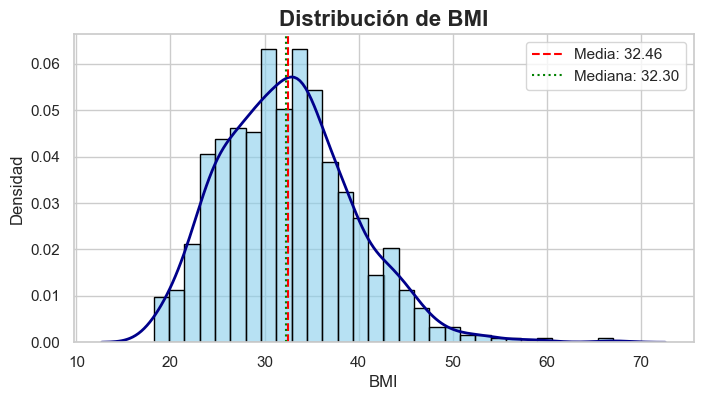

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo
sns.set(style="whitegrid")

plt.figure(figsize=(8,4))

# Histograma
sns.histplot(bmi, bins=30, stat="density", color="skyblue", edgecolor="black", alpha=0.6)

# KDE
sns.kdeplot(bmi, color="darkblue", linewidth=2)

# Líneas de referencia
plt.axvline(bmi.mean(), color="red", linestyle="--", label=f"Media: {bmi.mean():.2f}")
plt.axvline(bmi.median(), color="green", linestyle=":", label=f"Mediana: {bmi.median():.2f}")

# Títulos
plt.title("Distribución de BMI", fontsize=16, fontweight="bold")
plt.xlabel("BMI", fontsize=12)
plt.ylabel("Densidad", fontsize=12)

# Leyenda
plt.legend()

plt.show()

A partir de la gráfica se observan las siguientes características:

- La distribución del BMI es **unimodal**, con un único pico bien definido alrededor de valores cercanos a 30–32.

- Se observa una **asimetría positiva (sesgo a la derecha)**, lo cual se evidencia en:
  - Una cola más larga hacia valores altos  
  - La media ligeramente mayor que la mediana  

- La diferencia entre la media (32.46) y la mediana (32.30) confirma la presencia de esta asimetría, aunque no es extremadamente pronunciada.

- La cola derecha sugiere la existencia de valores elevados de BMI, lo cual es consistente con la presencia de casos de obesidad en la muestra.


Como se mencionó en el análisis descriptivo, la variable BMI presenta un comportamiento asimétrico con sesgo positivo, lo cual se confirma mediante la visualización.

En consecuencia:

- La distribución **no es simétrica**, por lo que modelos como la distribución normal no resultan adecuados.
- Se requieren distribuciones que:
  - Tengan soporte en valores positivos  
  - Permitan modelar asimetría  
  - Capturen adecuadamente el comportamiento en las colas  

Por lo tanto, distribuciones como **Lognormal, Gamma, Inversa Gaussiana y Log-Logistica** se consideran candidatas apropiadas para el ajuste.


### **<font color="navy">Ajuste de distribuciones</font>**

Con base en el análisis previo, se procede a ajustar distintas distribuciones teóricas a la variable BMI mediante el método de máxima verosimilitud (MLE).

Dado que la variable presenta valores positivos y asimetría a la derecha, se seleccionan distribuciones capaces de modelar este tipo de comportamiento.

Las distribuciones consideradas son:

- Normal
- Lognormal
- Gamma
- Weibull
- Inversa Gaussiana
- Log-Logistic
- Exponencial


Los parámetros de cada distribución se estiman mediante el método de **máxima verosimilitud (MLE)**, el cual consiste en encontrar los valores que maximizan la probabilidad de observar los datos.


En varias distribuciones (Lognormal, Gamma, Weibull, Inversa Gaussiana, entre otras), la implementación en `scipy` incluye un parámetro de localización (`loc`), que permite desplazar la distribución horizontalmente.

Sin embargo, dado que la variable BMI:

- Tiene soporte en valores positivos  
- No requiere desplazamiento para su interpretación  

Se fija este parámetro en cero (`loc = 0`) durante la estimación.

Esto permite:

- Mantener la coherencia teórica del modelo  
- Evitar ajustes artificiales  
- Garantizar una comparación consistente entre distribuciones  

De esta forma, los parámetros estimados corresponden únicamente a la forma y escala de cada distribución, reflejando de manera más adecuada la naturaleza de los datos.

### **<font color="navy">Parámetros estimados de las distribuciones</font>**

A continuación se presentan los parámetros estimados para cada distribución mediante el método de máxima verosimilitud.

Estos parámetros definen completamente cada modelo y serán utilizados posteriormente para evaluar la calidad del ajuste.

In [ ]:
# LIBRERÍAS

# numpy permite trabajar con arreglos numéricos y operaciones matemáticas
import numpy as np

# panda se usa para crear y manipular tablas (DataFrames)
import pandas as pd

# scipy.stats contiene distribuciones estadísticas y el método fit() que permite estimar parámetros mediante máxima verosimilitud (MLE)
from scipy import stats


# AJUSTE DE DISTRIBUCIONES
# Distribución Normal
# Ajusta dos parámetros: media (mu) y desviación estándar (sigma)
# No se fija loc porque la normal puede tomar valores negativos
params_norm = stats.norm.fit(bmi)


# Lognormal
# Modela variables positivas y asimétricas y se fija loc = 0 para evitar desplazar la distribución artificialmente
params_lognorm = stats.lognorm.fit(bmi, floc=0)

# Gamma
# Distribución positiva con capacidad de modelar asimetría y se fija loc = 0 para evitar desplazar la distribución artificialmente
params_gamma = stats.gamma.fit(bmi, floc=0)

# Weibull
# Se fija loc = 0 para evitar desplazar la distribución artificialmente
params_weibull = stats.weibull_min.fit(bmi, floc=0)


# Inverse Gaussian
# Modela colas largas y asimetría positiva y se fija loc = 0 para evitar desplazar la distribución artificialmente
params_invgauss = stats.invgauss.fit(bmi, floc=0)


# Log-Logistic (Fisk)
# Similar a lognormal, pero con colas más pesadas. Se fija loc = 0 para evitar desplazar la distribución artificialmente
params_loglogistic = stats.fisk.fit(bmi, floc=0)


# Exponencial
# Se fija loc = 0 para evitar desplazar la distribución artificialmente
params_exp = stats.expon.fit(bmi, floc=0)


# ORGANIZAR PARÁMETROS

# Esta función toma: el nombre de la distribución y los parámetros estimados (params)
# Y devuelve un diccionario con nombres interpretables
def unpack_params(name, params):

    # Normal
    if name == "Normal":
        # params = (mu, sigma)
        return {
            "mu": params[0],       # media
            "sigma": params[1]     # desviación estándar
        }

    # Exponencial
    elif name == "Exponencial":
        # params = (loc, scale)
        # lambda = 1 / scale
        return {
            "lambda": 1 / params[1]
        }

    # Lognormal
    elif name == "Lognormal":
        # params = (shape, loc, scale)
        return {
            "shape": params[0],    # controla la forma (asimetría)
            "scale": params[2]     # escala de la distribución
        }

    # Gamma
    elif name == "Gamma":
        return {
            "shape": params[0],
            "scale": params[2]
        }

    # Weibull
    elif name == "Weibull":
        return {
            "shape": params[0],
            "scale": params[2]
        }

    # Inversa Gaussian
    elif name == "InvGauss":
        return {
            "shape": params[0],
            "scale": params[2]
        }

    # Log-Logistica
    elif name == "Log-Logistic":
        return {
            "shape": params[0],
            "scale": params[2]
        }

    # Caso general
    else:
        return {"params": params}


# CREAR TABLA DE PARÁMETROS

# Lista vacía donde guardaremos cada fila
rows = []

# Diccionario con todas las distribuciones y sus parámetros
for name, params in {
    "Normal": params_norm,
    "Lognormal": params_lognorm,
    "Gamma": params_gamma,
    "Weibull": params_weibull,
    "InvGauss": params_invgauss,
    "Log-Logistic": params_loglogistic,
    "Exponencial": params_exp
}.items():

    # Creamos una fila con el nombre de la distribución
    row = {"Distribución": name}

    # Agregamos los parámetros (según la función anterior)
    row.update(unpack_params(name, params))

    # Guardamos la fila en la lista
    rows.append(row)


# Convertimos la lista en un DataFrame
params_df = pd.DataFrame(rows)

# Redondeamos los valores para mejor presentación
params_df = params_df.round(4)

# Mostramos la tabla final
params_df

,Distribución,mu,sigma,shape,scale,lambda
0,Normal,32.4575,6.9204,NaN,NaN,NaN
1,Lognormal,NaN,NaN,0.2122,31.7378,NaN
2,Gamma,NaN,NaN,22.4635,1.4449,NaN
3,Weibull,NaN,NaN,4.7523,35.2627,NaN
4,InvGauss,NaN,NaN,0.0460,705.0604,NaN
5,Log-Logistic,NaN,NaN,8.1945,31.8293,NaN
6,Exponencial,NaN,NaN,NaN,NaN,0.0308


### **<font color="navy">Comparación de densidades</font>**

Se comparan las funciones de densidad de las distribuciones ajustadas con la densidad empírica de los datos.

El histograma se presenta en escala de densidad y se acompaña de una estimación KDE, lo que permite visualizar la forma de los datos de manera continua.

Sobre esta base, se superponen las funciones de densidad teóricas de cada distribución, lo que permite evaluar visualmente qué modelo captura mejor:

- La forma general  
- La asimetría  
- El comportamiento en las colas  

Esta comparación es fundamental para identificar las distribuciones con mejor ajuste antes de aplicar criterios formales.

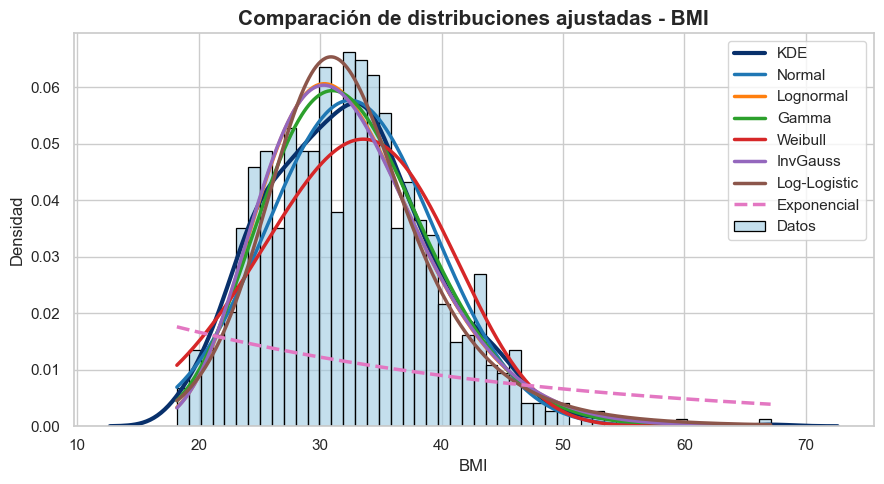

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")

plt.figure(figsize=(9,5))

sns.histplot(bmi,
             bins=50,
             stat="density",
             color="#9ecae1",
             edgecolor="black",
             alpha=0.6,
             label="Datos")

sns.kdeplot(bmi,
            color="#08306b",
            linewidth=3,
            label="KDE")

x = np.linspace(min(bmi), max(bmi), 500)

plt.plot(x,
         stats.norm.pdf(x, *params_norm),
         color="#1f77b4",
         linewidth=2.5,
         label="Normal")

plt.plot(x,
         stats.lognorm.pdf(x, *params_lognorm),
         color="#ff7f0e",
         linewidth=2.5,
         label="Lognormal")

plt.plot(x,
         stats.gamma.pdf(x, *params_gamma),
         color="#2ca02c",
         linewidth=2.5,
         label="Gamma")

plt.plot(x,
         stats.weibull_min.pdf(x, *params_weibull),
         color="#d62728",
         linewidth=2.5,
         label="Weibull")

plt.plot(x,
         stats.invgauss.pdf(x, *params_invgauss),
         color="#9467bd",
         linewidth=2.5,
         label="InvGauss")

plt.plot(x,
         stats.fisk.pdf(x, *params_loglogistic),
         color="#8c564b",
         linewidth=2.5,
         label="Log-Logistic")

plt.plot(x,
         stats.expon.pdf(x, *params_exp),
         color="#e377c2",
         linestyle="--",
         linewidth=2.5,
         label="Exponencial")

plt.title("Comparación de distribuciones ajustadas - BMI",
          fontsize=15,
          fontweight="bold")

plt.xlabel("BMI")
plt.ylabel("Densidad")

plt.legend()
plt.tight_layout()

plt.show()

Con el objetivo de analizar de manera más detallada el comportamiento de cada modelo, se presentan gráficas individuales en las que se compara la densidad teórica de cada distribución con la distribución empírica de los datos.

En cada caso, se incluye el histograma en escala de densidad y la estimación Kernel (KDE), lo que permite observar con mayor claridad qué tan bien cada distribución logra capturar:

- La forma general de los datos  
- La asimetría presente en la distribución  
- El comportamiento en las colas

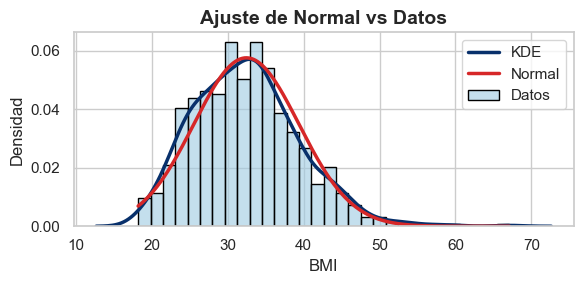

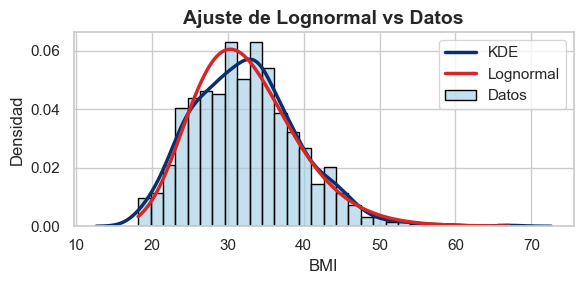

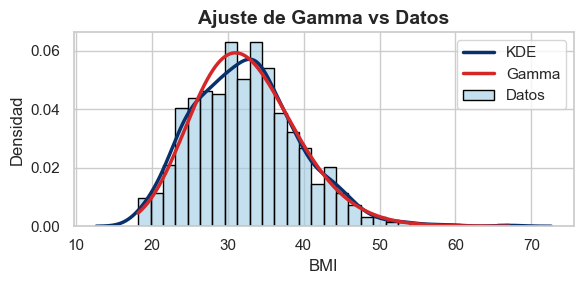

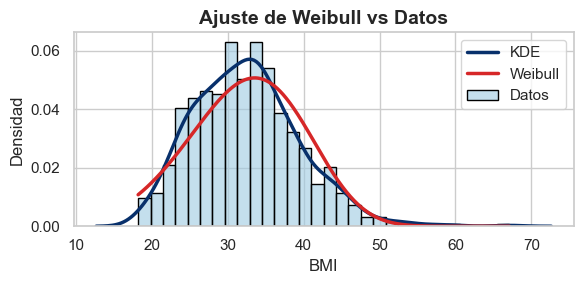

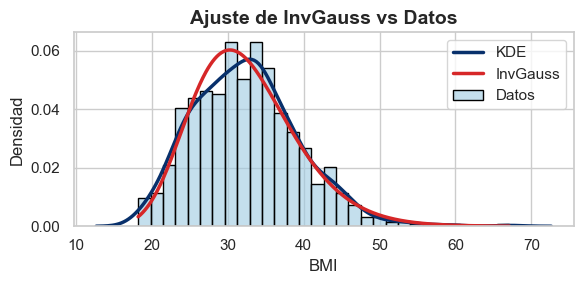

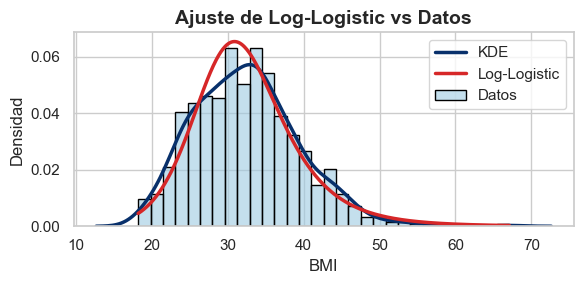

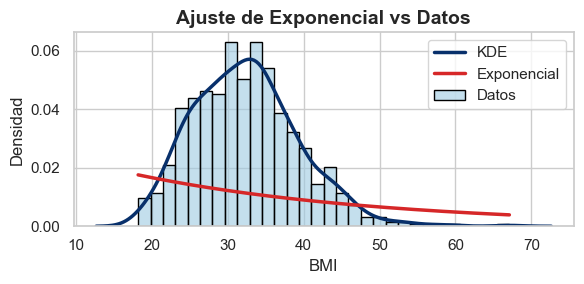

In [ ]:
# LIBRERÍAS

# numpy se usapara generar el rango de valores
import numpy as np

# matplotlib se usa para crear las gráficas
import matplotlib.pyplot as plt

# seaborn se usa para mejorar la estética de las gráficas
import seaborn as sns

# scipy.stats contiene las funciones de densidad (pdf)
from scipy import stats


# Se usa un estilo limpio con cuadrícula
sns.set(style="whitegrid")


# Se generan 500 puntos entre el mínimo y máximo del BMI. Esto permite evaluar las funciones de densidad de forma continua
x = np.linspace(min(bmi), max(bmi), 500)


# DICCIONARIO DE DISTRIBUCIONES
# Cada elemento contiene:
# - nombre de la distribución
# - función de scipy
# - parámetros estimados previamente (MLE)
dists = {
    "Normal": (stats.norm, params_norm),
    "Lognormal": (stats.lognorm, params_lognorm),
    "Gamma": (stats.gamma, params_gamma),
    "Weibull": (stats.weibull_min, params_weibull),
    "InvGauss": (stats.invgauss, params_invgauss),
    "Log-Logistic": (stats.fisk, params_loglogistic),
    "Exponencial": (stats.expon, params_exp)
}


# GENERACIÓN DE GRÁFICAS

# Se recorre cada distribución para crear una gráfica independiente
for name, (dist, params) in dists.items():

    # Crear nueva figura (una por distribución)
    plt.figure(figsize=(6,3))

    # HISTOGRAMA (DATOS REALES)
    sns.histplot(bmi,
                 bins=30,
                 stat="density",
                 color="#9ecae1",
                 edgecolor="black",
                 alpha=0.6,
                 label="Datos")


    # KDE (DENSIDAD EMPÍRICA)
    # Representa la forma real de los datos de manera suave

    sns.kdeplot(bmi,
                color="#08306b",
                linewidth=2.5,
                label="KDE")

    # PDF (DENSIDAD TEÓRICA)
    # dist.pdf(...) evalúa la función de densidad usando los parámetros estimados
    plt.plot(x,
             dist.pdf(x, *params),
             color="#d62728",
             linewidth=2.5,
             label=name)

    # DETALLES DE LA GRÁFICA
    # Título dinámico según la distribución
    plt.title(f"Ajuste de {name} vs Datos",
              fontsize=14,
              fontweight="bold")

    # Etiquetas de ejes
    plt.xlabel("BMI")
    plt.ylabel("Densidad")

    # Leyenda
    plt.legend()

    # Ajuste automático de márgenes
    plt.tight_layout()


    # MOSTRAR GRÁFICA
    plt.show()

A partir de la comparación entre la densidad empírica (KDE) y las funciones de densidad teóricas ajustadas, se observan diferencias importantes en la capacidad de cada modelo para representar los datos de BMI.

#### **<font color="purple">Ajuste en la región central</font>**

- Las distribuciones **Lognormal, Gamma, Inversa Gaussiana y Log-Logistica** presentan un buen ajuste en la región central de la distribución, logrando capturar adecuadamente el pico alrededor de valores cercanos a 30–32.

- La distribución **Normal** también logra aproximar la zona central, pero presenta limitaciones debido a su simetría.

- La distribución **Weibull** muestra un ajuste menos preciso en esta región, subestimando el pico de la distribución.

#### **<font color="purple">Simetría</font>**

- La distribución empírica presenta una **asimetría positiva**, lo cual es consistente con lo observado en el análisis descriptivo.

- Las distribuciones **Lognormal, Gamma, Inversa Gaussiana y Log-Logistic** logran capturar esta asimetría de manera adecuada.

- La distribución **Normal**, al ser simétrica, no logra representar correctamente este comportamiento.


#### **<font color="purple">Comportamiento en la cola derecha</font>**

- La cola derecha es particularmente relevante, ya que contiene valores elevados de BMI.

- Las distribuciones **Gamma e Inversa Gaussiana** muestran un mejor ajuste en esta región, capturando de forma más adecuada la disminución gradual de la densidad.

- La **Lognormal** y la **Log-Logistica** también presentan un buen desempeño, aunque con ligeras diferencias en la forma de la cola.

- La distribución **Normal** subestima la cola derecha, mientras que la **Exponencial** presenta un comportamiento completamente inadecuado, con una caída demasiado rápida.

#### **<font color="darkgreen">De manera general</font>**

- Las distribuciones **Lognormal, Gamma, Inverse Gaussian y Log-Logistica** son las que mejor representan la forma general de los datos.

- La **Normal** no es adecuada debido a su incapacidad para modelar la asimetría.

- La **Exponencial** presenta el peor desempeño, ya que no logra capturar ni el pico ni la forma general de la distribución.


No obstante, esta evaluación es de carácter exploratorio, por lo que la selección final del modelo se realizará mediante criterios cuantitativos como AIC, BIC, KS y Anderson-Darling.

### **<font color="navy">Selección de la mejor distribución</font>**

Para determinar de manera objetiva qué distribución describe mejor los datos de BMI, se emplean distintos criterios cuantitativos de ajuste.

#### **<font color="purple">Log-verosimilitud (LogLik)</font>**

La log-verosimilitud mide qué tan probable es observar los datos bajo un modelo específico.

Se define como:

$$
\log L(\theta) = \sum_{i=1}^{n} \log f(x_i \mid \theta)
$$

donde:
- $f(x_i \mid \theta)$ es la función de densidad de la distribución evaluada en $x_i$
- $\theta$ son los parámetros del modelo

**Interpretación:**
- Valores más altos indican mejor ajuste  
- Se busca **maximizar** la log-verosimilitud  


#### **<font color="purple">AIC (Akaike Information Criterion)</font>**

El AIC evalúa la calidad del modelo penalizando la complejidad:

$$
AIC = 2k - 2 \log L
$$

donde:
- $k$ es el número de parámetros del modelo  
- $\log L$ es la log-verosimilitud  

**Interpretación:**
- Menor valor indica mejor modelo  
- Balancea ajuste y complejidad  
- Evita sobreajuste  


#### **<font color="purple">BIC (Bayesian Information Criterion)</font>**

El BIC es similar al AIC, pero penaliza más fuertemente la complejidad:

$$
BIC = \log(n)k - 2 \log L
$$

donde:
- $n$ es el tamaño de la muestra  
- $k$ es el número de parámetros  

**Interpretación:**
- Menor valor indica mejor modelo  
- Favorece modelos más simples  
- Más estricto que AIC  

#### **<font color="purple">KS (Kolmogorov-Smirnov)</font>**

El estadístico KS mide la máxima diferencia entre la distribución empírica y la teórica:

$$
KS = \sup_x \left| F_n(x) - F(x) \right|
$$

donde:
- $F_n(x)$ es la función de distribución empírica  
- $F(x)$ es la función de distribución teórica  

**Interpretación:**
- Valores más pequeños indican mejor ajuste  
- Evalúa la forma general de la distribución  


#### **<font color="purple">AD (Anderson-Darling)</font>**

El estadístico Anderson-Darling da mayor peso a las colas de la distribución:

$$
A^2 = -n - \frac{1}{n} \sum_{i=1}^{n} (2i - 1)\left[\log F(x_i) + \log(1 - F(x_{n+1-i}))\right]
$$

**Interpretación:**
- Valores más pequeños indican mejor ajuste  
- Muy sensible en las colas  
- Importante cuando los valores extremos son relevantes  


#### **<font color="darkgreen">Criterio de selección</font>**

El mejor modelo será aquel que:

- Maximice la log-verosimilitud  
- Minimice AIC y BIC  
- Minimice KS y AD  

Dado que estos criterios evalúan distintos aspectos del ajuste, la selección final se realiza considerando un equilibrio entre ellos.

In [ ]:
# LIBRERÍAS

# numpy se utiliza para operaciones numéricas
import numpy as np

# pandas permite organizar los resultados en forma de tabla
import pandas as pd

# scipy.stats contiene funciones de distribuciones estadísticas y herramientas como logpdf, cdf y kstest
from scipy import stats


# FUNCIONES DE CRITERIO

# Log-verosimilitud
# Calcula qué tan probable es observar los datos (bmi) bajo una distribución específica con ciertos parámetros
def loglik(dist, params):
    # dist.logpdf(...) calcula log(f(x_i))
    # np.sum(...) suma sobre todos los datos
    return np.sum(dist.logpdf(bmi, *params))


# AIC (Akaike)
# Penaliza modelos con más parámetros. Busca equilibrio entre ajuste y complejidad
def AIC(ll, k):
    # ll = log-verosimilitud
    # k = número de parámetros
    return 2*k - 2*ll


# BIC (Bayesiano)
# Penaliza más fuerte que AIC cuando hay muchos datos

def BIC(ll, k, n):
    # n = tamaño de muestra
    return np.log(n)*k - 2*ll


# Anderson-Darling (AD)
# Evalúa qué tan bien la distribución ajusta las COLAS
def AD_statistic(x, dist, params):

    # Ordenar los datos de menor a mayor
    x_sorted = np.sort(x)

    # Calcular la CDF teórica (F(x))
    cdf = dist.cdf(x_sorted, *params)

    # Evitar problemas numéricos como log(0)
    cdf = np.clip(cdf, 1e-10, 1 - 1e-10)

    # Crear índice i = 1,2,...,n
    i = np.arange(1, len(x_sorted) + 1)

    # Fórmula del estadístico AD
    return -len(x_sorted) - np.mean(
        (2*i - 1) * (np.log(cdf) + np.log(1 - cdf[::-1]))
    )


# DEFINICIÓN DE DISTRIBUCIONES
# Diccionario donde:
# - clave = nombre de la distribución
# - valor = (objeto distribución, parámetros estimados)

dists = {
    "Normal": (stats.norm, params_norm),
    "Lognormal": (stats.lognorm, params_lognorm),
    "Gamma": (stats.gamma, params_gamma),
    "Weibull": (stats.weibull_min, params_weibull),
    "InvGauss": (stats.invgauss, params_invgauss),
    "Log-Logistic": (stats.fisk, params_loglogistic),
    "Exponencial": (stats.expon, params_exp)
}


# CÁLCULO DE MÉTRICAS
# Lista donde guardaremos los resultados de cada modelo
results = []

# Tamaño de muestra (necesario para BIC)
n = len(bmi)

# Iterar sobre cada distribución
for name, (dist, params) in dists.items():

    # Log-verosimilitud
    ll = loglik(dist, params)

    # Número de parámetros
    # Se usa para penalización en AIC y BIC
    k = len(params)

    # AIC y BIC
    aic = AIC(ll, k)
    bic = BIC(ll, k, n)

    # KS (Kolmogorov-Smirnov)
    # Compara la CDF empírica vs teórica
    ks_stat, _ = stats.kstest(bmi, dist.cdf, args=params)

    # AD (colas)
    ad = AD_statistic(bmi, dist, params)

    # Guardar resultados
    results.append([name, ll, aic, bic, ks_stat, ad])


# CREAR TABLA FINAL
tabla = pd.DataFrame(
    results,
    columns=["Distribución", "LogLik", "AIC", "BIC", "KS", "AD"]
)

# Ordenar por AIC (mejor modelo arriba)
tabla = tabla.sort_values(by="AIC").reset_index(drop=True)


# FORMATO DE RESULTADOS
# Redondear valores
tabla["LogLik"] = tabla["LogLik"].round(3)
tabla["AIC"] = tabla["AIC"].round(3)
tabla["BIC"] = tabla["BIC"].round(3)
tabla["KS"] = tabla["KS"].round(5)
tabla["AD"] = tabla["AD"].round(5)


# RESALTAR MEJORES VALORES
# Función para resaltar:
# - mínimo (AIC, BIC, KS, AD)
# - máximo (LogLik)

def highlight_best(s, is_min=True):

    if is_min:
        # resaltar el valor mínimo
        return ['background-color: lightgreen' if v == s.min() else '' for v in s]
    else:
        # resaltar el valor máximo
        return ['background-color: lightgreen' if v == s.max() else '' for v in s]


# Aplicar formato a la tabla
tabla_estilo = tabla.style \
    .apply(highlight_best, subset=["AIC", "BIC", "KS", "AD"], is_min=True) \
    .apply(highlight_best, subset=["LogLik"], is_min=False)


# MOSTRAR RESULTADO FINAL
tabla_estilo

,Distribución,LogLik,AIC,BIC,KS,AD
0,InvGauss,-2517.825000,5041.651000,5055.539000,0.037650,0.692270
1,Lognormal,-2517.959000,5041.918000,5055.806000,0.037260,0.693950
2,Gamma,-2519.234000,5044.467000,5058.355000,0.023140,0.399340
3,Log-Logistic,-2527.889000,5061.778000,5075.666000,0.036060,1.379580
4,Normal,-2538.534000,5081.069000,5090.327000,0.034970,1.989060
5,Weibull,-2573.340000,5152.680000,5166.568000,0.061840,6.845080
6,Exponencial,-3391.307000,6786.615000,6795.873000,0.453470,219.396540


A partir de los resultados obtenidos, se analizan los distintos criterios para evaluar la calidad del ajuste de cada distribución.

#### **<font color="purple">Log-verosimilitud (LogLik)</font>**

- La distribución **Inverse Gaussian** presenta el valor más alto de log-verosimilitud (-2517.825), lo que indica el mejor ajuste en términos de probabilidad de los datos.
- La **Lognormal** presenta un valor muy cercano, seguida de la **Gamma**.


#### **<font color="purple">AIC y BIC</font>**

- La **Inversa Gaussiana** presenta los valores más bajos tanto en AIC (5041.651) como en BIC (5055.539), lo que indica el mejor equilibrio entre ajuste y complejidad.
- La **Lognormal** también muestra un desempeño muy competitivo.
- La **Gamma** se encuentra ligeramente por debajo, pero sigue siendo una buena candidata.

#### **<font color="purple">KS (Kolmogorov-Smirnov)</font>**

- La **Gamma** presenta el valor más bajo (0.02314), lo que indica que es la que mejor reproduce la forma general de la distribución.
- Le siguen la **Normal**, la **Lognormal** y la **Inverse Gaussian**, con valores similares.


#### **<font color="purple">AD (Anderson-Darling)</font>**

- La **Gamma** presenta el menor valor (0.39934), indicando el mejor ajuste en las colas de la distribución.
- La **Inverse Gaussian** y la **Lognormal** también muestran buen desempeño.

---
**De namera general:**

- La **Inverse Gaussian** domina en:
  - Log-verosimilitud  
  - AIC  
  - BIC  

- La **Gamma** domina en:
  - KS (forma general)  
  - AD (colas)  

- La **Lognormal** muestra un desempeño consistente en todos los criterios.


Considerando todos los criterios:

- La **Inversa Gaussiana** se selecciona como el modelo principal, ya que presenta el mejor ajuste global en términos de verosimilitud y criterios de información.
  
- La **Gamma** se considera una excelente alternativa, especialmente por su desempeño superior en la representación de la forma y las colas de la distribución.

- La **Lognormal** también es una opción válida, con un desempeño equilibrado en todos los criterios.

## **<font color="navy">Intervalos de confianza (IC)</font>**

Para este punto un intervalo de confianza aparte de brindar el rango con una cierta probabilidad (nivel de confianza) también contiene el verdadero parámetro poblacional que se quiere estimar.

### **<font color="navy">Justificación del uso de la distribución Gamma</font>**

La distribución Gamma se utiliza en este análisis debido a que el índice de masa corporal (BMI) es una variable continua, estrictamente positiva y con una marcada asimetría hacia la derecha. Estas características son consistentes con la forma de la distribución Gamma, la cual está definida únicamente para valores mayores a cero y permite modelar adecuadamente datos sesgados.

Además, la distribución Gamma es flexible, ya que mediante sus parámetros de forma $(\alpha)$ y escala $(\beta)$ puede adaptarse a diferentes niveles de dispersión y asimetría, lo que la convierte en una opción adecuada para representar la variabilidad observada en el BMI.

En comparación con otras distribuciones, la Gamma mostró un buen desempeño en pruebas de ajuste como Kolmogorov-Smirnov (KS) y Anderson-Darling (AD), lo que indica una adecuada representación tanto del comportamiento general de los datos como de sus colas. Este último aspecto es relevante en contextos médicos, ya que los valores extremos de BMI pueden estar asociados a mayor riesgo de enfermedades como la diabetes.

Por estas razones, la distribución Gamma resulta apropiada para modelar el BMI en este estudio, permitiendo una representación estadísticamente coherente de su comportamiento y facilitando análisis posteriores.

In [ ]:
from scipy import stats            # Importa funciones estadísticas, incluida la distribución gamma

params_gamma = stats.gamma.fit(bmi, floc=0) #Genera los parámetros

alpha, loc, beta = params_gamma # Componentes

print(f"Parámetros estimados de la distribución gamma:")
print(f"alpha (forma): {alpha}")
print(f"loc (desplazamiento): {loc} (fijado en 0)")
print(f"beta (escala): {beta}")

Parámetros estimados de la distribución gamma:
alpha (forma): 22.463528779324363
loc (desplazamiento): 0 (fijado en 0)
beta (escala): 1.4448960353132567


In [ ]:
import numpy as np                  # Importa NumPy para manejo de arreglos y cálculos numéricos
from scipy import stats            # Importa funciones estadísticas, incluida la distribución gamma

data = bmi                         # Guarda tus datos (bmi) en una variable más corta

n_boot = 1000                      # Número de muestras bootstrap (mientras más grande, más precisión)
medias = []                        # Lista vacía donde guardaremos las medias calculadas

for _ in range(n_boot):            # Repite el proceso n_boot veces
    sample = np.random.choice(     # Genera una muestra aleatoria con reemplazo (bootstrap)
        data,
        size=len(data),            # La muestra tiene el mismo tamaño que los datos originales
        replace=True               # Permite repetir valores (clave en bootstrap)
    )

    alpha, loc, beta = stats.gamma.fit(sample, floc=0)
    # Ajusta una distribución gamma a la muestra
    # alpha = parámetro de forma (shape)
    # loc = desplazamiento (lo fijamos en 0 con floc=0)
    # beta = parámetro de escala (scale)

    media = alpha * beta           # Calcula la media de la gamma ajustada (media = α * β)

    medias.append(media)           # Guarda la media en la lista

lower = np.percentile(medias, 2.5)   # Percentil 2.5% → límite inferior del IC 95%
upper = np.percentile(medias, 97.5)  # Percentil 97.5% → límite superior del IC 95%

print(f"IC 95%: ({lower}, {upper})") # Imprime el intervalo de confianza

IC 95%: (31.960492073976223, 32.98153896961691)


Por lo tanto, con un $95\%$ de confianza, estimamos que el valor medio verdadero de la población se encuentra entre $31.96$ y $32.98$

### **<font color="navy">Justificación del uso de bootstrap para intervalos de confianza de la media (distribución gamma)</font>**

En este análisis se utilizó el método de **bootstrap** para estimar el intervalo de confianza de la media de una distribución gamma ajustada a los datos. Esta decisión se fundamenta en varias razones estadísticas:

1. **Complejidad analítica de la distribución**  
   La media de una distribución gamma depende de los parámetros estimados  $(\alpha)$ y $(\beta)$, los cuales se obtienen mediante métodos de máxima verosimilitud. La distribución exacta de estos estimadores no es trivial, lo que dificulta derivar intervalos de confianza analíticos precisos.

2. **Incorporación de la incertidumbre del modelo**  
   El bootstrap permite capturar no solo la variabilidad de los datos, sino también la incertidumbre asociada al proceso de estimación de los parámetros de la distribución gamma.

3. **Pocos supuestos**  
   A diferencia de los métodos paramétricos clásicos, el bootstrap no requiere asumir normalidad ni formas específicas para la distribución de la media estimada.

4. **Asimetría en los datos**  
   Los resultados indican que la distribución no es simétrica, por lo que la aproximación mediante una distribución normal podría no ser adecuada. En este contexto, el bootstrap resulta especialmente útil, ya que no depende de supuestos de simetría y puede adaptarse mejor a distribuciones sesgadas como la gamma.

5. **Flexibilidad y aplicabilidad**  
   Este método puede aplicarse independientemente de la complejidad del modelo, siempre que se pueda reestimar el parámetro de interés (en este caso, la media) a partir de muestras re-muestreadas.

6. **Aproximación empírica de la distribución**  
   El bootstrap construye una distribución empírica de la media mediante re-muestreo con reemplazo, lo que permite estimar directamente los percentiles que definen el intervalo de confianza.

En conjunto, el uso de bootstrap proporciona una forma robusta, general y computacionalmente accesible de estimar intervalos de confianza, especialmente cuando los datos presentan asimetría y las soluciones analíticas son difíciles o poco fiables.

## **<font color="navy">Análisis de experimentos unifactoriales en un diseño completamente aleatorio (ANOVA).</font>**

### **<font color="navy">Objetivo del Análisis</font>**

El propósito de este apartado es profundizar en el comportamiento de variables médicas clave mediante técnicas inferenciales, específicamente el Análisis de Varianza (ANOVA).

A diferencia del análisis exploratorio previo, que se enfoca en describir los datos, en esta sección buscamos **validar estadísticamente** si las diferencias observadas entre grupos son significativas o si podrían deberse al azar.

Buscamos identificar qué variables médicas influyen de manera determinante en el diagnóstico de diabetes ($Outcome$) y cómo varía el metabolismo según la edad.

**Las preguntas que planteamos en esta parte del proyecto tienen como objetivo entender mejor cómo se comportan ciertas variables importantes en distintos grupos de pacientes.**

No se trata solo de observar si cambian, sino de determinar si esas diferencias realmente son relevantes desde un punto de vista estadístico. Esto nos permite identificar qué variables podrían estar más relacionadas con la diabetes.

Además, estas preguntas nos ayudan a darle dirección al análisis y a enfocarnos en obtener conclusiones que tengan utilidad tanto para la interpretación de los datos como para posibles aplicaciones futuras.

### **<font color="navy">Glosario de Términos - Tabla ANOVA</font>**

<table style="border-collapse: collapse; width:100%;">

<tr style="background-color:black; color:white;">
<th style="padding:10px; border: 1px solid #ddd;">Término</th>
<th style="padding:10px; border: 1px solid #ddd;">Descripción</th>
</tr>

<tr style="background-color:#f9f9f9;">
<td style="padding:10px; border: 1px solid #ddd;"><b>SS (Suma de Cuadrados)</b></td>
<td style="padding:10px; border: 1px solid #ddd;">Mide la variabilidad total de los datos. Representa la suma de las desviaciones al cuadrado respecto a la media.</td>
</tr>

<tr>
<td style="padding:10px; border: 1px solid #ddd;"><b>GL (Grados de Libertad)</b></td>
<td style="padding:10px; border: 1px solid #ddd;">Número de comparaciones independientes que se pueden realizar en el conjunto de datos.</td>
</tr>

<tr style="background-color:#f9f9f9;">
<td style="padding:10px; border: 1px solid #ddd;"><b>MS (Cuadrado Medio)</b></td>
<td style="padding:10px; border: 1px solid #ddd;">Es la varianza calculada (la Suma de Cuadrados dividida entre los Grados de Libertad).</td>
</tr>

<tr>
<td style="padding:10px; border: 1px solid #ddd;"><b>F (Estadístico F)</b></td>
<td style="padding:10px; border: 1px solid #ddd;">Cociente de varianzas. Un valor elevado indica que la variabilidad entre grupos es mayor que la variabilidad interna, sugiriendo diferencias reales.</td>
</tr>

<tr style="background-color:#f9f9f9;">
<td style="padding:10px; border: 1px solid #ddd;"><b>P-valor</b></td>
<td style="padding:10px; border: 1px solid #ddd;">Probabilidad de que los resultados observados se deban al azar. Se considera estadísticamente significativo si es <b>menor a 0.05</b>.</td>
</tr>

</table>

In [ ]:
import numpy as np  # Manejo de arreglos y cálculos numéricos
import pandas as pd  # Manipulación de tablas de datos
import matplotlib.pyplot as plt  # Creación de gráficos básicos
import seaborn as sns  # Gráficos estadísticos avanzados
from scipy import stats  # Funciones matemáticas y distribuciones

# Carga del archivo de datos
df = pd.read_csv("diabetes.csv")  # Lectura del archivo CSV

# Limpieza de datos
# Filtra filas donde Glucosa, Presión e IMC sean mayores a cero
df_clean = df[(df['Glucose'] > 0) & (df['BloodPressure'] > 0) & (df['BMI'] > 0)].copy()

# Función para agrupar por edad
def categorizar_edad(edad):
    if 21 <= edad <= 30: return 'Joven'  # Rango de 21 a 30 años
    elif 31 <= edad <= 50: return 'Adulto'  # Rango de 31 a 50 años
    else: return 'Mayor'  # Mayores de 50 años

# Creación de la columna de grupos
df_clean['AgeGroup'] = df_clean['Age'].apply(categorizar_edad)  # Aplicación de la función


En el análisis de datos relacionados con la diabetes, es común identificar diferencias aparentes en variables clínicas como la glucosa, el índice de masa corporal (IMC) o la edad. Sin embargo, estas diferencias observadas no siempre garantizan que exista una relación real, ya que podrían deberse a la variabilidad natural de los datos.

El problema principal consiste en determinar si las diferencias entre grupos de pacientes (personas con diabetes y sin diabetes) son verdaderamente significativas desde un punto de vista estadístico.

A partir de esto:

### **<font color="navy">¿Existen diferencias significativas en los niveles de glucosa entre personas con y sin diabetes?</font>**


**Hipótesis:**
* $H_0: \mu_{0} = \mu_{1}$ No existen diferencias significativas en los niveles de glucosa entre los grupos.  
* $H_a: \mu_{0} \neq \mu_{1}$ Sí existen diferencias significativas en los niveles de glucosa entre los grupos.

In [ ]:
g0 = df_clean[df_clean['Outcome'] == 0]['Glucose']  # Datos de glucosa para grupo sano
g1 = df_clean[df_clean['Outcome'] == 1]['Glucose']  # Datos de glucosa para grupo diabético

f_stat, p_val = stats.f_oneway(g0, g1)  # Cálculo de la prueba ANOVA

# Cálculo de sumas de cuadrados
sst = sum((df_clean['Glucose'] - df_clean['Glucose'].mean())**2)  # Variabilidad total
sstr = sum(len(g) * (g.mean() - df_clean['Glucose'].mean())**2 for g in [g0, g1])  # Variabilidad entre grupos
sse = sst - sstr  # Variabilidad dentro de los grupos (error)

# Diccionario de resultados
data_anova = {
    "Fuente de Variación": ["Tratamientos", "Error", "Total"],
    "Suma de cuadrados": [f"{sstr:.2f}", f"{sse:.2f}", f"{sst:.2f}"],
    "GL": [1, len(df_clean)-2, len(df_clean)-1],  # Grados de libertad
    "Cuadrado medio": [f"{sstr/1:.2f}", f"{sse/(len(df_clean)-2):.2f}", ""],
    "F": [f"{f_stat:.4f}", "", ""],  # Valor F calculado
    "P-valor": [f"{p_val:.4e}", "", ""]  # Valor p resultante
}

# Representación de la tabla
pd.DataFrame(data_anova).style.hide(axis="index")\
    .set_properties(**{"text-align": "center", "padding": "8px"})\
    .set_table_styles([{"selector": "th", "props": [("background-color", "#2a7fba"), ("color", "white"), ("font-weight", "bold")]}])

Fuente de Variación,Suma de cuadrados,GL,Cuadrado medio,F,P-valor
Tratamientos,163061.94,1,163061.94,226.1525,1.1502e-44
Error,520581.08,722,721.03,,
Total,683643.02,723,,,


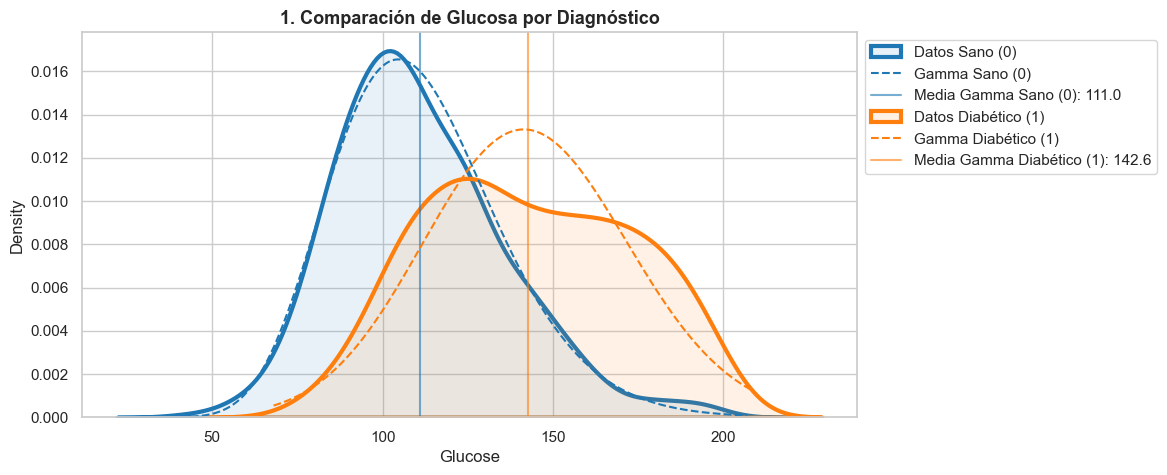

In [ ]:
sns.set(style="whitegrid")  # Configuración del fondo del gráfico
plt.figure(figsize=(10, 5))  # Dimensiones de la figura

colores = ["#1f77b4", "#ff7f0e"]  # Definición de colores
categorias = [0, 1]  # Identificadores de diagnóstico

for i, cat in enumerate(categorias):
    valores = df_clean[df_clean['Outcome'] == cat]['Glucose']  # Selección de glucosa por grupo
    etiqueta = "Sano (0)" if cat == 0 else "Diabético (1)"  # Etiqueta de texto

    # Gráfico de densidad real
    sns.kdeplot(valores, color=colores[i], fill=True, alpha=0.1, linewidth=3, label=f"Datos {etiqueta}")

    # Ajuste de distribución Gamma
    shape, loc, scale = stats.gamma.fit(valores)  # Estimación de parámetros Gamma
    x = np.linspace(valores.min()-10, valores.max()+10, 200)  # Rango de valores para el eje X

    # Dibujo de la curva Gamma teórica
    plt.plot(x, stats.gamma.pdf(x, shape, loc, scale), color=colores[i], linestyle="--", label=f"Gamma {etiqueta}")

    # Cálculo y dibujo de la media poblacional
    mu_gamma = (shape * scale) + loc  # Fórmula de la esperanza matemática Gamma
    plt.axvline(mu_gamma, color=colores[i], alpha=0.6, label=f"Media Gamma {etiqueta}: {mu_gamma:.1f}")

plt.title("1. Comparación de Glucosa por Diagnóstico", fontsize=13, fontweight="bold")
plt.legend(bbox_to_anchor=(1, 1))  # Posición de la leyenda
plt.show()  # Visualización del gráfico

### **<font color="navy">Conclusiones**

Con un estadístico **F = 226.15** rechazamos la hipótesis nula. La glucosa es, por tanto, una variable determinante y estadísticamente diferente según el diagnóstico. Es decir, las personas con diabetes tienen niveles de azúcar en sangre mucho más altos que las personas sin diabetes. Esto confirma que la glucosa es un buen indicador para detectar la enfermedad.

### **<font color="navy">Interpretación de la gráfica**

Las personas con diabetes presentan niveles de glucosa notablemente más altos que las personas sin diabetes.

- Promedio sin diabetes: 111 mg/dL

- Promedio con diabetes: 143 mg/dL

Esta diferencia de 32 mg/dL es clínicamente significativa y consistente con los criterios médicos establecidos.



La presión arterial es una variable relevante en la salud general de los pacientes, y podría estar relacionada con la diabetes. Sin embargo, es necesario validar si existen diferencias significativas entre los grupos ya mencionados.


### **<font color="navy">¿Existen diferencias significativas en la presión arterial entre personas con y sin diabetes?</font>**

**Hipótesis:**
* $H_0: \mu_{0} = \mu_{1}$ No existen diferencias significativas en la presión arterial entre los grupos.
* $H_a: \mu_{0} \neq \mu_{1}$ Sí existen diferencias significativas en la presión arterial entre los grupos.

In [ ]:
g0 = df_clean[df_clean['Outcome'] == 0]['BloodPressure']  # Presión arterial en grupo sano
g1 = df_clean[df_clean['Outcome'] == 1]['BloodPressure']  # Presión arterial en grupo diabético

f_stat, p_val = stats.f_oneway(g0, g1)  # Prueba ANOVA para presión arterial

# Sumas de cuadrados
sst = sum((df_clean['BloodPressure'] - df_clean['BloodPressure'].mean())**2)  # Variabilidad total
sstr = sum(len(g) * (g.mean() - df_clean['BloodPressure'].mean())**2 for g in [g0, g1])  # Entre grupos
sse = sst - sstr  # Dentro de grupos

# Creación de tabla estilizada
pd.DataFrame({
    "Fuente de Variación": ["Tratamientos", "Error", "Total"],
    "Suma de cuadrados": [f"{sstr:.2f}", f"{sse:.2f}", f"{sst:.2f}"],
    "GL": [1, len(df_clean)-2, len(df_clean)-1],
    "Cuadrado medio": [f"{sstr/1:.2f}", f"{sse/(len(df_clean)-2):.2f}", ""],
    "F": [f"{f_stat:.4f}", "", ""],
    "P-valor": [f"{p_val:.4e}", "", ""]
}).style.hide(axis="index").set_properties(**{"text-align": "center", "padding": "8px"}).set_table_styles([
    {"selector": "th", "props": [("background-color", "#2a7fba"), ("color", "white"), ("font-weight", "bold")]}
])

Fuente de Variación,Suma de cuadrados,GL,Cuadrado medio,F,P-valor
Tratamientos,3079.35,1,3079.35,20.6379,6.5020e-06
Error,107728.49,722,149.21,,
Total,110807.84,723,,,


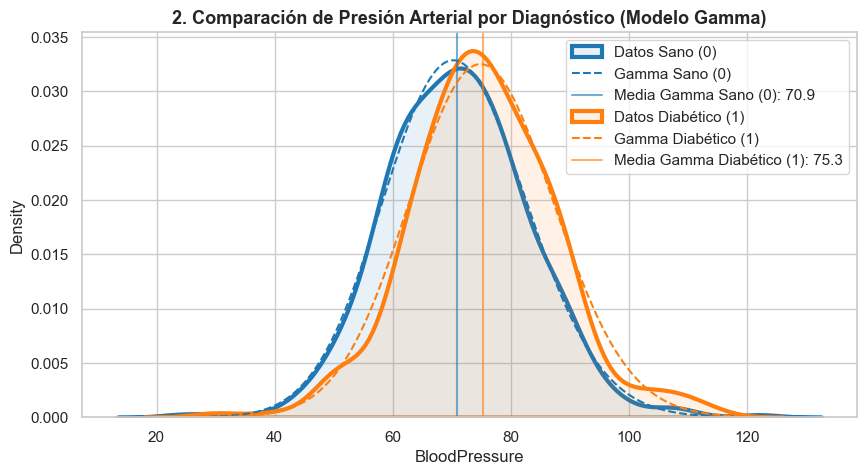

In [ ]:
plt.figure(figsize=(10, 5))  # Tamaño de figura
colores = ["#1f77b4", "#ff7f0e"]  # Colores para grupos
categorias = [0, 1]  # Categorías de Outcome

for i, cat in enumerate(categorias):
    valores = df_clean[df_clean['Outcome'] == cat]['BloodPressure']  # Filtro por categoría
    etiqueta = "Sano (0)" if cat == 0 else "Diabético (1)"  # Asignación de nombre

    # Gráfico de densidad observada
    sns.kdeplot(valores, color=colores[i], fill=True, alpha=0.1, linewidth=3, label=f"Datos {etiqueta}")

    # Ajuste Gamma
    shape, loc, scale = stats.gamma.fit(valores)  # Obtención de parámetros Gamma
    x = np.linspace(valores.min()-10, valores.max()+10, 200)  # Eje X continuo

    # Curva Gamma ajustada
    plt.plot(x, stats.gamma.pdf(x, shape, loc, scale), color=colores[i], linestyle="--", label=f"Gamma {etiqueta}")

    # Línea vertical de la media poblacional
    mu_gamma = (shape * scale) + loc  # Media basada en parámetros Gamma
    plt.axvline(mu_gamma, color=colores[i], alpha=0.6, label=f"Media Gamma {etiqueta}: {mu_gamma:.1f}")

plt.title("2. Comparación de Presión Arterial por Diagnóstico (Modelo Gamma)", fontsize=13, fontweight="bold")
plt.legend(bbox_to_anchor=(1, 1))  # Leyenda
plt.show()  # Despliegue

### **<font color="navy">Conclusiones**

El valor de **F = 20.63** confirma que existe una diferencia significativa entre las medias, pero el efecto es menor. Aunque estadísticamente los grupos no son iguales, la presión arterial diastólica es un factor que contribuye de forma moderada al diagnóstico clínico. Entonces:
- La presión arterial sí es una variable relevante asociada a la diabetes.

- Las personas con diabetes tienden a tener presiones arteriales más elevadas, lo que es clínicamente importante porque:

    - La hipertensión es un factor de riesgo cardiovascular.

    - Los pacientes con diabetes deben monitorear su presión arterial como parte de su control médico.

- Sin embargo, el solapamiento de las curvas nos recuerda que no todas las personas con diabetes tienen presión alta, y no todas las personas con presión alta tienen diabetes.

### **<font color="navy">Interpretación de la gráfica**

A diferencia de la glucosa, las campanas de la presión arterial muestran un **solapamiento considerable**. Si bien la media del grupo con diabetes es ligeramente superior, las distribuciones comparten gran parte de su área, lo que indica que esta variable no tiene la misma capacidad discriminante que la glucosa.

La edad puede influir en diversas variables de salud, incluyendo los niveles de glucosa. Así que:

### **<font color="navy">¿Existen diferencias significativas en los niveles de glucosa entre distintos rangos de edad?**

**Hipótesis:**

* $H_0: \mu_{0} = \mu_{1}$ No existen diferencias significativas en los niveles de glucosa entre los rangos de edad.  
* $H_a: \mu_{0} \neq \mu_{1}$ Sí existen diferencias significativas en los niveles de glucosa entre los rangos de edad.

In [ ]:
gj = df_clean[df_clean['AgeGroup'] == 'Joven']['Glucose']  # Glucosa en grupo Joven
ga = df_clean[df_clean['AgeGroup'] == 'Adulto']['Glucose']  # Glucosa en grupo Adulto
gm = df_clean[df_clean['AgeGroup'] == 'Mayor']['Glucose']  # Glucosa en grupo Mayor

f_stat, p_val = stats.f_oneway(gj, ga, gm)  # Prueba ANOVA para tres grupos

# Sumas de cuadrados para edad
sst = sum((df_clean['Glucose'] - df_clean['Glucose'].mean())**2)  # Total
sstr = sum(len(g) * (g.mean() - df_clean['Glucose'].mean())**2 for g in [gj, ga, gm])  # Entre edades
sse = sst - sstr  # Error

# Generación de tabla ANOVA
pd.DataFrame({
    "Fuente de Variación": ["Tratamientos", "Error", "Total"],
    "Suma de cuadrados": [f"{sstr:.2f}", f"{sse:.2f}", f"{sst:.2f}"],
    "GL": [2, len(df_clean)-3, len(df_clean)-1],  # 2 grados de libertad entre grupos
    "Cuadrado medio": [f"{sstr/2:.2f}", f"{sse/(len(df_clean)-3):.2f}", ""],
    "F": [f"{f_stat:.4f}", "", ""],
    "P-valor": [f"{p_val:.4e}", "", ""]
}).style.hide(axis="index").set_properties(**{"text-align": "center", "padding": "8px"}).set_table_styles([
    {"selector": "th", "props": [("background-color", "#2a7fba"), ("color", "white"), ("font-weight", "bold")]}
])

Fuente de Variación,Suma de cuadrados,GL,Cuadrado medio,F,P-valor
Tratamientos,49026.96,2,24513.48,27.8503,2.2348e-12
Error,634616.06,721,880.19,,
Total,683643.02,723,,,


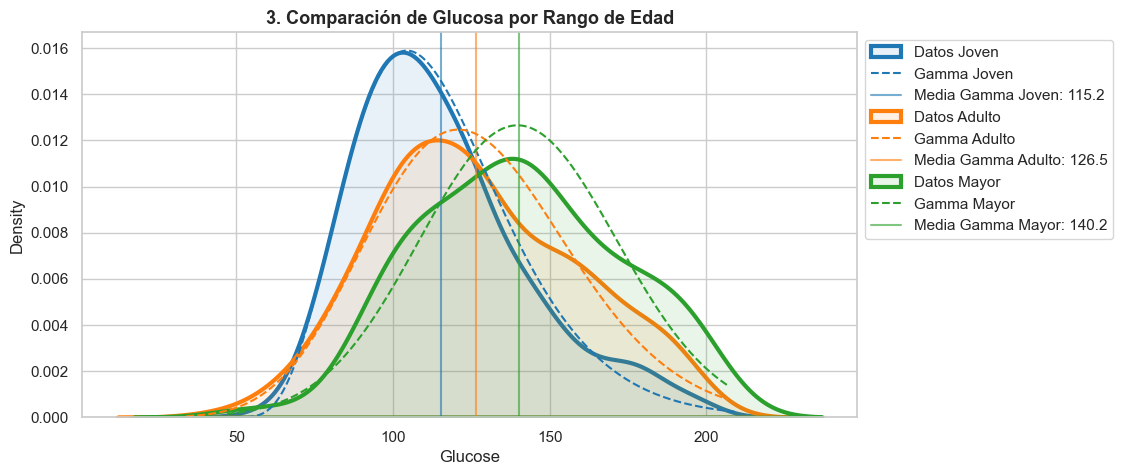

In [ ]:
plt.figure(figsize=(10, 5))  # Configuración del lienzo
colores = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # Colores para los tres grupos
categorias = ['Joven', 'Adulto', 'Mayor']  # Nombres de las categorías

for i, cat in enumerate(categorias):
    valores = df_clean[df_clean['AgeGroup'] == cat]['Glucose']  # Filtro por edad

    # Densidad de los datos reales
    sns.kdeplot(valores, color=colores[i], fill=True, alpha=0.1, linewidth=3, label=f"Datos {cat}")

    # Ajuste Gamma poblacional
    shape, loc, scale = stats.gamma.fit(valores)  # Parámetros Gamma por edad
    x = np.linspace(valores.min()-10, valores.max()+10, 200)  # Puntos X

    # Trazado de curva Gamma
    plt.plot(x, stats.gamma.pdf(x, shape, loc, scale), color=colores[i], linestyle="--", label=f"Gamma {cat}")

    # Marcado de media poblacional
    mu_gamma = (shape * scale) + loc  # Media Gamma calculada
    plt.axvline(mu_gamma, color=colores[i], alpha=0.6, label=f"Media Gamma {cat}: {mu_gamma:.1f}")

plt.title("3. Comparación de Glucosa por Rango de Edad", fontsize=13, fontweight="bold")
plt.legend(bbox_to_anchor=(1, 1))  # Ubicación de leyenda
plt.show()  # Mostrar gráfico

### **<font color="navy">Conclusiones**

Con un estadístico **F = 27.85**, confirmamos que la edad tiene un efecto significativo sobre los niveles de glucosa. Por lo tanto:
- La edad es un factor determinante en los niveles de glucosa.

- A medida que aumenta la edad, los niveles de glucosa tienden a elevarse, lo cual es clínicamente relevante porque:

    - La tolerancia a la glucosa disminuye con la edad.

    - Las personas mayores tienen mayor riesgo de desarrollar diabetes o prediabetes.

    - Los programas de prevención y detección temprana deben enfocarse especialmente en adultos mayores.




### **<font color="navy">Interpretación de la gráfica**

En este análisis de tres niveles, se observa un **desplazamiento escalonado**. A medida que la categoría de edad avanza de Joven a Mayor, la media de la glucosa se desplaza hacia la derecha. Esto sugiere una relación positiva entre el envejecimiento y el aumento de los niveles de glucosa en plasma.
Observaciones:
- Las tres curvas están claramente separadas y se desplazan hacia la derecha a medida que aumenta la edad.

- Existe poco solapamiento entre los grupos extremos (jóvenes vs mayores).

- El solapamiento moderado entre jóvenes y adultos, y entre adultos y mayores, indica que aunque hay diferencias promedio, algunas personas jóvenes pueden tener glucosa alta y algunos mayores pueden tener glucosa controlada.

El IMC es un indicador relacionado con el sobrepeso y la obesidad, factores que podrían influir en la presencia de diabetes.
Entonces:

### **<font color="navy">¿El Indice de Masa Corporal (BMI) promedio difiere entre pacientes con y sin diabetes?**

**Hipótesis:**

* $H_0: \mu_{0} = \mu_{1}$ No existen diferencias significativas en el BMI entre los grupos.   
* $H_a: \mu_{0} \neq \mu_{1}$ Sí existen diferencias significativas en el BMI entre los grupos.

In [ ]:
g0 = df_clean[df_clean['Outcome'] == 0]['BMI']  # Datos de IMC en grupo sano
g1 = df_clean[df_clean['Outcome'] == 1]['BMI']  # Datos de IMC en grupo diabético

f_stat, p_val = stats.f_oneway(g0, g1)  # Prueba ANOVA para IMC

# Cálculos de variabilidad
sst = sum((df_clean['BMI'] - df_clean['BMI'].mean())**2)  # Total
sstr = sum(len(g) * (g.mean() - df_clean['BMI'].mean())**2 for g in [g0, g1])  # Entre grupos
sse = sst - sstr  # Dentro de grupos

# Construcción de la tabla de resultados
pd.DataFrame({
    "Fuente de Variación": ["Tratamientos", "Error", "Total"],
    "Suma de cuadrados": [f"{sstr:.2f}", f"{sse:.2f}", f"{sst:.2f}"],
    "GL": [1, len(df_clean)-2, len(df_clean)-1],
    "Cuadrado medio": [f"{sstr/1:.2f}", f"{sse/(len(df_clean)-2):.2f}", ""],
    "F": [f"{f_stat:.4f}", "", ""],
    "P-valor": [f"{p_val:.4e}", "", ""]
}).style.hide(axis="index").set_properties(**{"text-align": "center", "padding": "8px"}).set_table_styles([
    {"selector": "th", "props": [("background-color", "#2a7fba"), ("color", "white"), ("font-weight", "bold")]}
])

Fuente de Variación,Suma de cuadrados,GL,Cuadrado medio,F,P-valor
Tratamientos,3075.21,1,3075.21,71.0803,1.8572e-16
Error,31236.57,722,43.26,,
Total,34311.78,723,,,


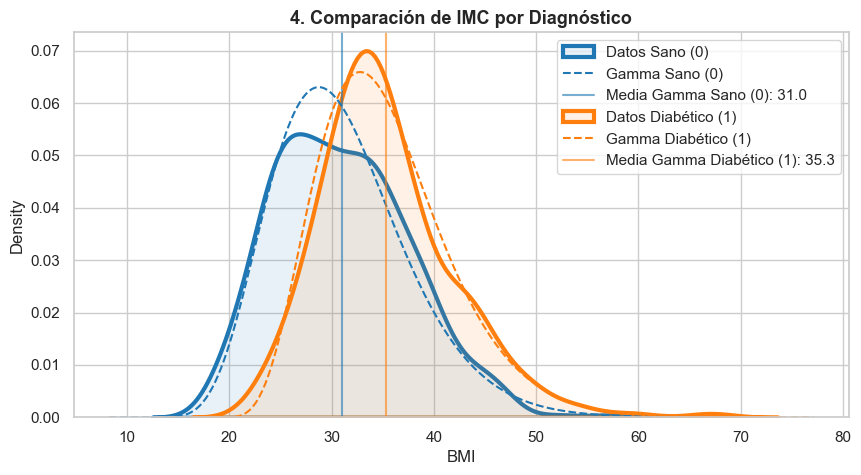

In [ ]:
plt.figure(figsize=(10, 5))  # Definición de tamaño
colores = ["#1f77b4", "#ff7f0e"]  # Colores para diagnóstico
categorias = [0, 1]  # Diagnósticos

for i, cat in enumerate(categorias):
    valores = df_clean[df_clean['Outcome'] == cat]['BMI']  # Selección de IMC
    etiqueta = "Sano (0)" if cat == 0 else "Diabético (1)"  # Etiqueta de grupo

    # Gráfico de densidad real (KDE)
    sns.kdeplot(valores, color=colores[i], fill=True, alpha=0.1, linewidth=3, label=f"Datos {etiqueta}")

    # Ajuste de distribución Gamma
    shape, loc, scale = stats.gamma.fit(valores)  # Parámetros Gamma para IMC
    x = np.linspace(valores.min()-10, valores.max()+10, 200)  # Rango eje X

    # Curva teórica Gamma
    plt.plot(x, stats.gamma.pdf(x, shape, loc, scale), color=colores[i], linestyle="--", label=f"Gamma {etiqueta}")

    # Dibujo de media poblacional Gamma
    mu_gamma = (shape * scale) + loc  # Media estimada
    plt.axvline(mu_gamma, color=colores[i], alpha=0.6, label=f"Media Gamma {etiqueta}: {mu_gamma:.1f}")

plt.title("4. Comparación de IMC por Diagnóstico", fontsize=13, fontweight="bold")
plt.legend(bbox_to_anchor=(1, 1))  # Leyenda externa
plt.show()  # Visualización final

### **<font color="navy">Conclusión de la Prueba**

El estadístico **F = 71.08** indica una diferencia de medias muy robusta. Se rechaza la hipótesis nula, estableciendo que el Índice de Masa Corporal es un indicador clave en la distinción de pacientes diabéticos en esta población.

### **<font color="navy">Interpretación de la gráfica**

Las campanas del IMC muestran una **separación notable**, solo superada por la variable glucosa. Los pacientes con diabetes presentan una media de IMC visiblemente mayor, lo que refuerza visualmente la hipótesis de que el sobrepeso es un factor de riesgo primario para la enfermedad.
Ambos grupos se encuentran en rangos de obesidad, pero el grupo con diabetes presenta un grado de obesidad más severo:

- Las personas con diabetes presentan un IMC promedio de 35.3, lo que se clasifica como obesidad.

- Las personas sin diabetes presentan un IMC promedio de 31.0, lo que se clasifica como obesidad grado I.
